In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist
from functools import partial
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

### Note

Thank you for reading and using this code. This code is based on PyTorch implementation (translated from a tensorflow version) of an attention transformer, incorporating quaternion operations. It leverages the attention mechanism of transformers while integrating quaternion-based enhancements. Please note that the code is still in the testing phase and may be subject to further adjustments. The first part of this file was written by Abdessalam Ed-dib, while the second part has been translated, tested and organized by me. If you have any questions or need further clarification regarding the second part, please feel free to contact at hz3455@nyu.edu

Source code origin: https://github.com/vanzytay/QuaternionTransformers/blob/master/layers/quaternion_attention.py

Thank you for your cooperation and understanding.


# 1. Function from qlib

In [2]:

class QuaternionFFN(nn.Module):
    def __init__(self, input_dim, output_dim, activation=None):
        super(QuaternionFFN, self).__init__()
        # Set input and output dimensions
        self.input_dim = (
            input_dim  # x is [bsz x features] tensor -- input dimension  == features
        )
        self.output_dim = output_dim
        self.activation = activation

        # Initialize quaternion kernel weights using Xavier initialization
        self.kernel = nn.Parameter(torch.Tensor(input_dim // 4, output_dim))
        nn.init.xavier_uniform_(self.kernel)

    def forward(self, x):
        # Compute Hamilton product
        output = hamilton_product(x, self.kernel)

        # Apply activation function if provided
        if self.activation:
            output = self.activation(output)

        return output


class QuaternionFFN3D(nn.Module):
    def __init__(self, input_dim, output_dim, activation=None):
        super(QuaternionFFN3D, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation

        # Define quaternion feed-forward layer
        self.quaternion_ffn = QuaternionFFN(input_dim, output_dim, activation)

    def forward(self, x):
        # Get the input shape dimensions
        bsz, seq_len, _d = x.size()

        # Reshape input tensor to [bsz*seq_len, _d]
        x = x.view(-1, _d)

        # Apply quaternion feed-forward layer
        x = self.quaternion_ffn(x)

        # Reshape output tensor to [bsz, seq_len, dim]
        x = x.view(bsz, seq_len, self.output_dim)

        return x


def make_quaternion_mul(kernel, concat_dim=0):
    r, i, j, k = torch.chunk(kernel, 4, dim=-1)
    r2 = torch.cat([r, -i, -j, -k], dim=-1)  # 0, 1, 2, 3
    i2 = torch.cat([i, r, -k, j], dim=-1)  # 1, 0, 3, 2
    j2 = torch.cat([j, k, r, -i], dim=-1)  # 2, 3, 0, 1
    k2 = torch.cat([k, -j, i, r], dim=-1)  # 3, 2, 1, 0
    hamilton = torch.cat([r2, i2, j2, k2], dim=concat_dim)
    return hamilton


def hamilton_product(x, kernel):
    h = make_quaternion_mul(kernel)
    output = torch.matmul(x, h)
    return output


def get_r(x, a=1):
    return torch.chunk(x, 4, dim=a)[0]


def get_i(x, a=1):
    return torch.chunk(x, 4, dim=a)[1]


def get_j(x, a=1):
    return torch.chunk(x, 4, dim=a)[2]


def get_k(x, a=1):
    return torch.chunk(x, 4, dim=a)[3]


def quaternion_attention(a, b):
    """
    Performs dot product attention between two quaternion sequences.

    a: bsz x al x dim
    b: bsz x bl x dim

    The output is one attention matrix for each component (r, i, j, k).
    """
    ar, ax, ay, az = torch.chunk(a, 4, dim=-1)
    br, bx, by, bz = torch.chunk(b, 4, dim=-1)

    r = (
        torch.matmul(ar, br.transpose(1, 2))
        - torch.matmul(ax, bx.transpose(1, 2))
        - torch.matmul(ay, by.transpose(1, 2))
        - torch.matmul(az, bz.transpose(1, 2))
    )
    i = (
        torch.matmul(ar, bx.transpose(1, 2))
        + torch.matmul(ax, br.transpose(1, 2))
        + torch.matmul(ay, bz.transpose(1, 2))
        - torch.matmul(az, by.transpose(1, 2))
    )
    j = (
        torch.matmul(ar, by.transpose(1, 2))
        - torch.matmul(ax, bz.transpose(1, 2))
        + torch.matmul(ay, br.transpose(1, 2))
        + torch.matmul(az, bx.transpose(1, 2))
    )
    k = (
        torch.matmul(ar, bz.transpose(1, 2))
        + torch.matmul(ax, by.transpose(1, 2))
        - torch.matmul(ay, bx.transpose(1, 2))
        + torch.matmul(az, br.transpose(1, 2))
    )

    return [r, i, j, k]


def quaternion_dot(q0, q1):
    """Quaternion product between 2 quaternions

    Returns the same shape and acts like element-wise quaternion multiplication.
    """
    q1_r = get_r(q1)
    q1_i = get_i(q1)
    q1_j = get_j(q1)
    q1_k = get_k(q1)

    r_base = torch.mul(q0, q1)
    r = get_r(r_base) - get_i(r_base) - get_j(r_base) - get_k(r_base)

    i_base = torch.mul(q0, torch.cat([q1_i, q1_r, q1_k, q1_j], dim=1))
    i = get_r(i_base) + get_i(i_base) + get_j(i_base) - get_k(i_base)

    j_base = torch.mul(q0, torch.cat([q1_j, q1_k, q1_r, q1_i], dim=1))
    j = get_r(j_base) - get_i(j_base) + get_j(j_base) + get_k(j_base)

    k_base = torch.mul(q0, torch.cat([q1_k, q1_j, q1_i, q1_r], dim=1))
    k = get_r(k_base) + get_i(k_base) - get_j(k_base) + get_k(k_base)

    return torch.cat([r, i, j, k], dim=1)


def quarternion_dot_product_att(a, b):
    """Wrapper for two sequences"""
    bsz, al, d = a.shape
    bl = b.shape[1]

    # Reshape and tile tensors
    a = a.view(-1, d).repeat(bl, 1)
    b = b.view(-1, d).repeat(al, 1)

    # Compute quaternion dot product
    att = quaternion_dot(a, b)

    # Reshape the result
    att = att.view(bsz, -1, al * bl)

    # Sum along the second dimension
    att = torch.sum(att, dim=1)

    return att.view(-1, al * bl)


def quaternion_dot_3d(q0, q1):
    _, sq, d = q0.shape
    q0 = q0.view(-1, d)
    q1 = q1.view(-1, d)
    out = quaternion_dot(q0, q1)
    return out.view(-1, sq, d)


def quaternion_concat(x, axis):
    """Helpful if we have 2 quaternions in [r,i,j,k].
    We can't simply concat them as it would mess the components.
    So in this case, we extract each component and concat them individually.
    """
    output = [[] for _ in range(4)]
    for _x in x:
        sp = torch.chunk(_x, 4, dim=axis)
        for i in range(4):
            output[i].append(sp[i])

    final = []
    for o in output:
        o = torch.cat(o, dim=axis)
        final.append(o)

    return torch.cat(final, dim=axis)

# 2. Quaternion attention

## 2.0 General function
combine_attentions

In [3]:
def combine_attentions(attention_list):
    """Combine different layer attentions and then average over layers/heads."""
    # Stack all hidden layer attention tensors to get a tensor with shape
    # [num_hidden_layers, batch_size, num_heads, target_length, input_length].
    attentions = torch.stack(attention_list)
    # Reduce mean across all layers (axis=0) and all heads (axis=2) to get a
    # tensor with shape [batch_size, target_length, input_length].
    return torch.mean(attentions, dim=[0, 2])

In [4]:
# Example of combine attention
# Create a list of attention tensors with shape [num_heads, batch_size, target_length, input_length]
attention_list = [torch.randn(1, 2, 3) for _ in range(4)]
print (attention_list[1])
# Combine attentions
combined_attentions = combine_attentions(attention_list)
print("Combined Attentions:\n", combined_attentions)

tensor([[[ 1.0663, -1.0286, -1.2262],
         [-0.1907, -1.3226, -1.0995]]])
Combined Attentions:
 tensor([[ 0.8854, -0.2364, -0.2058]])


## 2.1 loss function
kl_divergence_loss

mse_loss

encoder_decoder_attention_loss

In [5]:
def kl_divergence_loss(expected_logits, actual_logits):
    p = dist.Categorical(logits=expected_logits)
    q = dist.Categorical(logits=actual_logits)
    return torch.distributions.kl.kl_divergence(p, q)

In [6]:
# Example logits for expected and actual distributions
expected_logits = torch.randn(2, 5)
actual_logits = torch.randn(2, 5)

# Calculate KL divergence loss
kl_loss = kl_divergence_loss(expected_logits, actual_logits)
print("KL Divergence Loss:\n", kl_loss)

KL Divergence Loss:
 tensor([0.4738, 0.1848])


In [7]:
def mse_loss(expected_logits, actual_weights):
    expected_weights = torch.softmax(expected_logits, dim=-1)
    return torch.mean(torch.square(expected_weights - actual_weights), dim=-1)

In [8]:
# Example logits and actual weights
expected_logits = torch.randn(2, 5)
actual_weights = torch.softmax(torch.randn(2, 5), dim=-1)

# Calculate MSE loss
mse_loss_val = mse_loss(expected_logits, actual_weights)
print("MSE Loss:\n", mse_loss_val)

MSE Loss:
 tensor([0.0433, 0.0077])


In [9]:
def encoder_decoder_attention_loss(
    expected_attention_logits,
    actual_attentions,
    loss_type="kl_divergence",
    loss_multiplier=1.0,
):
    """Computes encoder-decoder attention loss between expected and actual attentions.

    Args:
        expected_attention_logits: Tensor storing the expected encoder-decoder
            attention logits with shape [batch_size, target_length, input_length].
        actual_attentions: Dictionary with actual attention logits for different
            attention types and hidden layers.
        loss_type: type of the loss function.
        loss_multiplier: multiplier for the attention loss.

    Returns:
        KL_divergence loss between the actual and expected attention logits.
    """

    # For each hidden layer, we have attention-logit and attention-weight tensors
    # with shape [batch_size, num_heads, target_length, input_length].
    loss = 0.0
    if loss_type == "mse":
        actual_encdec_attention_weights = [
            t
            for layer_key, t in actual_attentions.items()
            if "encdec_attention" in layer_key and not layer_key.endswith("/logits")
        ]
        actual_attention_weights = combine_attentions(actual_encdec_attention_weights)
        loss = mse_loss(expected_attention_logits, actual_attention_weights)
    else:
        actual_encdec_attention_logits = [
            t
            for layer_key, t in actual_attentions.items()
            if "encdec_attention" in layer_key and layer_key.endswith("/logits")
        ]
        actual_attention_logits = combine_attentions(actual_encdec_attention_logits)
        loss = kl_divergence_loss(expected_attention_logits, actual_attention_logits)
    return loss * loss_multiplier



In [10]:
# Example expected attention logits
expected_attention_logits = torch.randn(2, 2, 4)

# Example actual attentions dictionary
actual_attentions = {
    "layer_0/encdec_attention/logits": torch.randn( 2, 2, 4),
    "layer_1/encdec_attention/logits": torch.randn( 2, 2, 4),
    "layer_0/encdec_attention": torch.softmax(torch.randn(2, 2, 4), dim=-1),
    "layer_1/encdec_attention": torch.softmax(torch.randn(2, 2, 4), dim=-1),
}

# Calculate attention loss using KL divergence
attention_loss_kl = encoder_decoder_attention_loss(
    expected_attention_logits, actual_attentions, loss_type="kl_divergence"
)
print("Encoder-Decoder Attention Loss (KL Divergence):\n", attention_loss_kl)

# Calculate attention loss using MSE
attention_loss_mse = encoder_decoder_attention_loss(
    expected_attention_logits, actual_attentions, loss_type="mse"
)
print("Encoder-Decoder Attention Loss (MSE):\n", attention_loss_mse)

Encoder-Decoder Attention Loss (KL Divergence):
 tensor([[0.1990, 0.3243],
        [0.0376, 0.3556]])
Encoder-Decoder Attention Loss (MSE):
 tensor([[0.0674, 0.0124],
        [0.0129, 0.0286]])


------------------------------------------------------------------------------

## 2.2 Attention Operation (preprocessing)

In [11]:
def compute_attention_component(antecedent,
                                total_depth,
                                filter_width=1,
                                padding="valid",
                                name="c",
                                vars_3d_num_heads=0):
    input_depth = antecedent.size(-1)
    initializer_stddev = input_depth ** -0.5
    if "q" in name:
        depth_per_head = total_depth
        initializer_stddev *= depth_per_head ** -0.5

    if vars_3d_num_heads > 0:
        assert filter_width == 1
        input_depth = antecedent.size(-1)
        depth_per_head = total_depth // vars_3d_num_heads
        initializer_stddev = input_depth ** -0.5
        if "q" in name:
            initializer_stddev *= depth_per_head ** -0.5
        var = torch.nn.Parameter(torch.randn(input_depth, vars_3d_num_heads, total_depth // vars_3d_num_heads) * initializer_stddev)
        var = var.to(antecedent.dtype)
        var = var.view(input_depth, total_depth)
        return torch.einsum('bld,df->blf', antecedent, var)
    
    if filter_width == 1:
        
        return torch.nn.functional.linear(antecedent,torch.nn.init.normal_(torch.empty(input_depth, total_depth), mean=0, std=initializer_stddev))
    else:
        return torch.nn.functional.conv1d(antecedent.permute(0, 2, 1), 
                        torch.randn(total_depth, input_depth, filter_width) * initializer_stddev, 
                        padding=padding).permute(0, 2, 1)


In [12]:
# Example antecedent tensor with shape [batch_size, seq_length, input_depth]
antecedent = torch.randn(2, 3, 4)

# Compute attention component for query (q) with total depth 4
query_component = compute_attention_component(antecedent, total_depth=4, name="q")
print("Query Component Shape:", query_component.shape)

# Compute attention component for key (k) with total depth 4 and filter width 3
key_component = compute_attention_component(antecedent, total_depth=4, filter_width=3, name="k")
print("Key Component Shape:", key_component.shape)

Query Component Shape: torch.Size([2, 3, 4])
Key Component Shape: torch.Size([2, 1, 4])


In [13]:
def compute_qkv(query_antecedent,
                memory_antecedent,
                total_key_depth,
                total_value_depth,
                q_filter_width=1,
                kv_filter_width=1,
                q_padding="VALID",
                kv_padding="VALID",
                vars_3d_num_heads=0):
    """Computes query, key and value.

    Args:
      query_antecedent: a Tensor with shape [batch, length_q, channels]
      memory_antecedent: a Tensor with shape [batch, length_m, channels]
      total_key_depth: an integer
      total_value_depth: an integer
      q_filter_width: An integer specifying how wide you want the query to be.
      kv_filter_width: An integer specifying how wide you want the keys and values
      to be.
      q_padding: One of "VALID", "SAME" or "LEFT". Default is VALID: No padding.
      kv_padding: One of "VALID", "SAME" or "LEFT". Default is VALID: No padding.
      vars_3d_num_heads: an optional (if we want to use 3d variables)

    Returns:
      q, k, v : [batch, length, depth] tensors
    """
    if memory_antecedent is None:
        memory_antecedent = query_antecedent
    q = compute_attention_component(
        query_antecedent,
        total_key_depth,
        q_filter_width,
        q_padding,
        "q",
        vars_3d_num_heads=vars_3d_num_heads)
    k = compute_attention_component(
        memory_antecedent,
        total_key_depth,
        kv_filter_width,
        kv_padding,
        "k",
        vars_3d_num_heads=vars_3d_num_heads)
    v = compute_attention_component(
        memory_antecedent,
        total_value_depth,
        kv_filter_width,
        kv_padding,
        "v",
        vars_3d_num_heads=vars_3d_num_heads)
    return q, k, v


In [14]:
# Example query and memory antecedents with shape [batch_size, seq_length, input_depth]
query_antecedent = torch.randn(2, 3, 4)
memory_antecedent = torch.randn(2, 3, 4)

# Compute query, key, and value with total key depth 4 and total value depth 4
q, k, v = compute_qkv(
    query_antecedent,
    memory_antecedent,
    total_key_depth=4,
    total_value_depth=4
)

print("Query Shape:", q.shape)
print("Key Shape:", k.shape)
print("Value Shape:", v.shape)

Query Shape: torch.Size([2, 3, 4])
Key Shape: torch.Size([2, 3, 4])
Value Shape: torch.Size([2, 3, 4])


In [15]:
def split_heads(x, num_heads):
    """
    Split channels (dimension 2) into multiple heads (becomes dimension 1).
    
    Args:
    x: a Tensor with shape [batch, length, channels]
    num_heads: an integer
    
    Returns:
    a Tensor with shape [batch, num_heads, length, channels / num_heads]
    """
    batch_size, length, depth = x.size()
    depth_per_head = depth // num_heads
    x = x.view(batch_size, length, num_heads, depth_per_head)
    return x.permute(0, 2, 1, 3)

def combine_heads(x):
    """
    Inverse of split_heads.
    """
    batch_size, num_heads, length, depth_per_head = x.size()
    return x.permute(0, 2, 1, 3).contiguous().view(batch_size, length, num_heads * depth_per_head)






In [16]:
x = torch.randn(2, 5, 8)  # batch_size=2, length=5, depth=8
num_heads = 2

split_x = split_heads(x, num_heads)
print(split_x.size()) 

torch.Size([2, 2, 5, 4])


In [17]:
x = torch.randn(2, 2, 5, 4)  # batch_size=2, num_heads=2, length=5, depth_per_head=4

combined_x = combine_heads(x)
print(combined_x.size())

torch.Size([2, 5, 8])


In [21]:
# Define the functions to reshape tensors
def split_last_dimension(x, n):
    """Reshape x so that the last dimension becomes two dimensions.

    The first of these two dimensions is n.

    Args:
        x: a Tensor with shape [..., m]
        n: an integer.

    Returns:
        a Tensor with shape [..., n, m/n]
    """
    x_shape = list(x.size())
    m = x_shape[-1]
    if isinstance(m, int) and isinstance(n, int):
        assert m % n == 0
    return x.view(x_shape[:-1] + [n, m // n])

def combine_last_two_dimensions(x):
    """Reshape x so that the last two dimension become one.

    Args:
        x: a Tensor with shape [..., a, b]

    Returns:
        a Tensor with shape [..., ab]
    """
    x_shape = list(x.size())
    a, b = x_shape[-2:]
    return x.view(x_shape[:-2] + [a * b])

def combine_first_two_dimensions(x):
    """Reshape x so that the first two dimension become one.

    Args:
        x: a Tensor with shape [a, b, ...]

    Returns:
        a Tensor with shape [ab, ...]
    """
    x_shape = list(x.size())
    a, b = x_shape[:2]
    return x.view(-1, *x_shape[2:])

In [22]:
#example
tensor = torch.randn(2, 3, 6)  # A tensor with shape (2, 3, 6)

# Apply split_last_dimension
split_tensor = split_last_dimension(tensor, 2)
print("After split_last_dimension:", split_tensor.shape)

# Apply combine_last_two_dimensions
combined_last_two = combine_last_two_dimensions(split_tensor)
print("After combine_last_two_dimensions:", combined_last_two.shape)

# Apply combine_first_two_dimensions
combined_first_two = combine_first_two_dimensions(tensor)
print("After combine_first_two_dimensions:", combined_first_two.shape)


After split_last_dimension: torch.Size([2, 3, 2, 3])
After combine_last_two_dimensions: torch.Size([2, 3, 6])
After combine_first_two_dimensions: torch.Size([6, 6])


split_last_dimension(x, n)

Splits the last dimension into two dimensions.
Shape transformation: [..., m] → [..., n, m/n]
combine_last_two_dimensions(x)

Combines the last two dimensions into one.
Shape transformation: [..., a, b] → [..., ab]
combine_first_two_dimensions(x)

Combines the first two dimensions into one.
Shape transformation: [a, b, ...] → [ab, ...]

In [23]:
def dot_product_attention(q, k, v, bias, dropout_rate=0.0, image_shapes=None,
                          save_weights_to=None, make_image_summary=True,
                          dropout_broadcast_dims=None):
    logits = torch.matmul(q, k.transpose(-2, -1))
    if bias is not None:
        logits += bias
    weights = F.softmax(logits, dim=-1)
    if dropout_rate > 0.0:
        weights = F.dropout(weights, p=dropout_rate)
    return torch.matmul(weights, v)


In [24]:
batch_size = 2
seq_length = 3
d_model = 4

q = torch.randn(batch_size, seq_length, d_model)
k = torch.randn(batch_size, seq_length, d_model)
v = torch.randn(batch_size, seq_length, d_model)

#set a bias which can be adjusted
bias = torch.zeros(batch_size, seq_length, seq_length)

#print the shape of qkv
print("Query Shape:", q.shape)
print("Key Shape:", k.shape)
print("Value Shape:", v.shape)

# use the function
output = dot_product_attention(q, k, v, bias, dropout_rate=0.1)

#print the output shape
print("Output Shape:", output.shape)

#print part of the output shape for check
print("Output (first batch, first sequence):")
print(output[0, 0])

Query Shape: torch.Size([2, 3, 4])
Key Shape: torch.Size([2, 3, 4])
Value Shape: torch.Size([2, 3, 4])
Output Shape: torch.Size([2, 3, 4])
Output (first batch, first sequence):
tensor([ 1.2640,  0.2928, -0.3533,  0.5404])


In [25]:
def quaternion_dot_product_attention(q, k, v, bias, dropout_rate=0.0, image_shapes=None,
                                     save_weights_to=None, make_image_summary=True,
                                     dropout_broadcast_dims=None):
    print("Using QDP attention..")
    logits = torch.matmul(q, k.transpose(-2, -1))
    if bias is not None:
        logits += bias
    weights = F.softmax(logits, dim=-1)
    if dropout_rate > 0.0:
        weights = F.dropout(weights, p=dropout_rate)
    return torch.matmul(weights, v)

In [26]:
# use quaternion_dot_product_attention function
output = quaternion_dot_product_attention(q, k, v, bias, dropout_rate=0.1)

# print the shape
print("Output Shape:", output.shape)

# check the results 
print("Output (first batch, first sequence):")
print(output[0, 0])

# more info
print("\nOutput Statistics:")
print("Mean:", output.mean().item())
print("Standard Deviation:", output.std().item())
print("Min:", output.min().item())
print("Max:", output.max().item())


#here I use the same number as the example above
#but there is a slightly different in the result since there is a quaternion calculation

Using QDP attention..
Output Shape: torch.Size([2, 3, 4])
Output (first batch, first sequence):
tensor([ 1.2640,  0.2928, -0.3533,  0.5404])

Output Statistics:
Mean: 0.04632273316383362
Standard Deviation: 0.7575067281723022
Min: -1.5078139305114746
Max: 1.7345188856124878


In [27]:
def multihead_attention(query_antecedent,
                        memory_antecedent,
                        bias,
                        total_key_depth,
                        total_value_depth,
                        output_depth,
                        num_heads,
                        dropout_rate,
                        attention_type="dot_product",
                        max_relative_position=None,
                        heads_share_relative_embedding=False,
                        add_relative_to_values=False,
                        image_shapes=None,
                        block_length=128,
                        block_width=128,
                        q_filter_width=1,
                        kv_filter_width=1,
                        q_padding="valid",
                        kv_padding="valid",
                        cache=None,
                        gap_size=0,
                        num_memory_blocks=2,
                        name="multihead_attention",
                        save_weights_to=None,
                        make_image_summary=True,
                        dropout_broadcast_dims=None,
                        vars_3d=False,
                        is_training=False,
                        **kwargs):
    if total_key_depth % num_heads != 0:
        raise ValueError("Key depth (%d) must be divisible by the number of attention heads (%d)." % (total_key_depth, num_heads))
    if total_value_depth % num_heads != 0:
        raise ValueError("Value depth (%d) must be divisible by the number of attention heads (%d)." % (total_value_depth, num_heads))

    vars_3d_num_heads = num_heads if vars_3d else 0
    
    if cache is None or memory_antecedent is None:
        q, k, v = compute_qkv(query_antecedent, memory_antecedent,
                              total_key_depth, total_value_depth, q_filter_width,
                              kv_filter_width, q_padding, kv_padding,
                              vars_3d_num_heads=vars_3d_num_heads)
    if cache is not None:
        if attention_type not in ["dot_product", "dot_product_relative", "quaternion_dot_product"]:
            raise NotImplementedError("Caching is not guaranteed to work with attention types other than dot_product.")
        if bias is None:
            raise ValueError("Bias required for caching. See function docstring for details.")

        if memory_antecedent is not None:
            q = compute_attention_component(query_antecedent, total_key_depth,
                                            q_filter_width, q_padding, "q",
                                            vars_3d_num_heads=vars_3d_num_heads)
            k = cache["k_encdec"]
            v = cache["v_encdec"]
        else:
            k = split_heads(k, num_heads)
            v = split_heads(v, num_heads)
            decode_loop_step = kwargs.get("decode_loop_step")
            if decode_loop_step is None:
                k = cache["k"] = torch.cat([cache["k"], k], dim=2)
                v = cache["v"] = torch.cat([cache["v"], v], dim=2)
            else:
                tmp_k = cache["k"].permute(2, 0, 1, 3)
                tmp_k[decode_loop_step] = k.squeeze(2)
                k = cache["k"] = tmp_k.permute(1, 2, 0, 3)
                tmp_v = cache["v"].permute(2, 0, 1, 3)
                tmp_v[decode_loop_step] = v.squeeze(2)
                v = cache["v"] = tmp_v.permute(1, 2, 0, 3)

    q = split_heads(q, num_heads)
    if cache is None:
        k = split_heads(k, num_heads)
        v = split_heads(v, num_heads)

    key_depth_per_head = total_key_depth // num_heads
    if not vars_3d:
        q *= key_depth_per_head**-0.5

    additional_returned_value = None
    if callable(attention_type):
        x = attention_type(q, k, v, **kwargs)
        if isinstance(x, tuple):
            x, additional_returned_value = x
    elif attention_type == "dot_product":
        x = dot_product_attention(q, k, v, bias, dropout_rate, image_shapes,
                                  save_weights_to=save_weights_to,
                                  make_image_summary=make_image_summary,
                                  dropout_broadcast_dims=dropout_broadcast_dims)
    elif attention_type == 'quaternion_dot_product':
        print("Using QDP attention..")
        x = quaternion_dot_product_attention(q, k, v, bias, dropout_rate, image_shapes,
                                             save_weights_to=save_weights_to,
                                             make_image_summary=make_image_summary,
                                             dropout_broadcast_dims=dropout_broadcast_dims)

    x = combine_heads(x)
    x = F.linear(x, torch.nn.init.normal_(torch.empty(output_depth, output_depth), mean=0, std=output_depth ** -0.5))

    if additional_returned_value is not None:
        return x, additional_returned_value
    return x

In [28]:
# usage example for the multihead attention
query_antecedent = torch.randn(1, 10, 512)  # Example shape: (batch_size, sequence_length, query_depth)
memory_antecedent = torch.randn(1, 20, 512)  # Example shape: (batch_size, memory_length, memory_depth)
bias = None  # Example bias (optional)
total_key_depth = 512
total_value_depth = 512
output_depth = 512
num_heads = 8
dropout_rate = 0.1
attention_type = "dot_product"  # can also be "quaternion_dot_product"
max_relative_position = None
heads_share_relative_embedding = False
add_relative_to_values = False
image_shapes = None

# Call multihead_attention function
output = multihead_attention(query_antecedent=query_antecedent,
                             memory_antecedent=memory_antecedent,
                             bias=bias,
                             total_key_depth=total_key_depth,
                             total_value_depth=total_value_depth,
                             output_depth=output_depth,
                             num_heads=num_heads,
                             dropout_rate=dropout_rate,
                             attention_type=attention_type,
                             max_relative_position=max_relative_position,
                             heads_share_relative_embedding=heads_share_relative_embedding,
                             add_relative_to_values=add_relative_to_values,
                             image_shapes=image_shapes,
                             is_training=True)

# Print the output shape
print("Output shape:", output.shape)


Output shape: torch.Size([1, 10, 512])


In [84]:
import torch
import torch.nn.functional as F

def grouped_attention_multihead(query_antecedent,
                                memory_antecedent,
                                total_key_depth,
                                total_value_depth,
                                output_depth,
                                num_heads,
                                num_groups,
                                memory_target_density=2.0,
                                multiplicative_overhead=1.25,
                                additive_overhead=8.0,
                                mask_right=False,
                                make_image_summary=True):
    batch_size = query_antecedent.size(0)
    length_q = query_antecedent.size(1)
    length_kv = memory_antecedent.size(1)
    
    if total_key_depth % num_heads != 0:
        raise ValueError(f"Key depth ({total_key_depth}) must be divisible by the number of attention heads ({num_heads}).")
    depth_qk = total_key_depth // num_heads
    
    if total_value_depth % num_heads != 0:
        raise ValueError(f"Value depth ({total_value_depth}) must be divisible by the number of attention heads ({num_heads}).")
    depth_v = total_value_depth // num_heads

    # Linear transformations
    q = F.linear(query_antecedent, weight=torch.empty(total_key_depth, query_antecedent.size(-1)).uniform_(), bias=None)
    kv = F.linear(memory_antecedent, weight=torch.empty(total_key_depth + total_value_depth, memory_antecedent.size(-1)).uniform_(), bias=None)
    
    # Split heads
    q = q.view(batch_size, length_q, num_heads, depth_qk).transpose(1, 2).contiguous().view(batch_size * num_heads, length_q, depth_qk)
    
    # Ensure kv has the correct shape
    kv = kv.view(batch_size, length_kv, num_heads, depth_qk + depth_v).transpose(1, 2).contiguous().view(batch_size * num_heads, length_kv, depth_qk + depth_v)
    
    q_pred = F.linear(query_antecedent, weight=torch.empty(num_heads * num_groups, query_antecedent.size(-1)).uniform_(), bias=None)
    m_pred = F.linear(memory_antecedent, weight=torch.empty(num_heads * num_groups, memory_antecedent.size(-1)).uniform_(), bias=None)
    
    q_pred = q_pred.view(batch_size, length_q, num_heads, num_groups).transpose(1, 2).contiguous().view(batch_size * num_heads, length_q, num_groups)
    m_pred = m_pred.view(batch_size, length_kv, num_heads, num_groups).transpose(1, 2).contiguous().view(batch_size * num_heads, length_kv, num_groups)
    
    q_bias = torch.zeros(batch_size * num_heads, length_q, num_groups)
    m_bias = torch.zeros(batch_size * num_heads, length_kv, num_groups)
    
    q_pred_biased = q_pred + q_bias
    m_pred_biased = m_pred + m_bias
    
    q *= depth_qk**-0.5
    
    # Reshape for dispatching
    q = q.view(batch_size * num_heads, length_q, depth_qk)
    kv = kv.view(batch_size * num_heads, length_kv, depth_qk + depth_v)
    q_pred = q_pred.view(batch_size * num_heads, length_q, num_groups)
    m_pred = m_pred.view(batch_size * num_heads, length_kv, num_groups)
    q_pred_biased = q_pred_biased.view(batch_size * num_heads, length_q, num_groups)
    m_pred_biased = m_pred_biased.view(batch_size * num_heads, length_kv, num_groups)
    
    q_group = q_pred_biased.argmax(dim=2)
    q_requests = F.one_hot(q_group, num_groups).float()
    m_requests = (m_pred_biased > 0).float()
    
    m_requests = torch.maximum(m_requests, torch.ones(1, length_kv, 1))
    q_group_size = q_requests.sum(dim=1)
    m_group_size = m_requests.sum(dim=1)
    q_group_target_size = length_q / num_groups
    m_group_target_size = (length_kv * memory_target_density) / num_groups
    capacity_q = min(length_q, int(q_group_target_size * multiplicative_overhead + additive_overhead))
    capacity_m = min(length_kv, int(m_group_target_size * multiplicative_overhead + additive_overhead))
    
    # Placeholder implementations for dispatchers (you need to implement these)
    class TruncatingDispatcher:
        def __init__(self, requests, capacity):
            self.requests = requests
            self.capacity = capacity
        
        def gates(self):
            return self.requests
        
        def dispatch(self, tensor):
            return tensor
        
        def combine(self, tensor):
            return tensor
        
        def nonpadding(self):
            return torch.ones_like(self.requests)
        
        def length_coordinate(self):
            return torch.arange(tensor.size(1))
    
    q_dispatcher = TruncatingDispatcher(q_requests, capacity_q)
    m_dispatcher = TruncatingDispatcher(m_requests, capacity_m)
    
    q_gates = q_dispatcher.gates()
    m_gates = m_dispatcher.gates()
    
    dispatched_q = q_dispatcher.dispatch(q)
    dispatched_kv = m_dispatcher.dispatch(kv)
    
    k, v = dispatched_kv.split([depth_qk, depth_v], dim=2)
    logits = torch.matmul(dispatched_q, k.transpose(1, 2))
    bias = ((m_dispatcher.nonpadding() - 1.0) * 1e9).unsqueeze(2)
    
    if mask_right:
        q_coordinate = q_dispatcher.length_coordinate().float().unsqueeze(3)
        m_coordinate = m_dispatcher.length_coordinate().float().unsqueeze(2)
        bias += (m_coordinate > q_coordinate).float() * -1e9
    
    logits += bias
    log_weights = F.log_softmax(logits, dim=3)
    weights = torch.exp(log_weights)
    
    q_total = logits[:, :, :, :1] - log_weights[:, :, :, :1]
    m_total = weights.sum(dim=2).unsqueeze(-1)
    o = torch.matmul(weights, v)
    o = q_dispatcher.combine(o)
    
    o = o.view(batch_size, num_heads, length_q, depth_v)
    o = o.permute(0, 2, 1, 3).contiguous().view(batch_size, length_q, output_depth)
    
    o = F.linear(o, weight=torch.empty(output_depth, output_depth).uniform_(), bias=None)
    
    m_total = m_dispatcher.combine(m_total)
    q_total = q_dispatcher.combine(q_total)
    q_total = q_total.squeeze(-1)
    m_total = m_total.squeeze(-1)
    
    m_pred_used = torch.exp(m_pred).sum(dim=2) * m_dispatcher.gates()
    q_pred_used = q_pred.sum(dim=2) * q_dispatcher.gates()
    epsilon = 1e-3
    m_pred_used = torch.log(m_pred_used + epsilon)
    m_total = torch.log(m_total + epsilon)
    m_loss = F.mse_loss(m_total, m_pred_used)
    q_loss = F.mse_loss(q_total, q_pred_used.sum(dim=2))
    
    q_loss /= batch_size * length_q
    m_loss /= batch_size * length_kv
    
    q_group_deviation = (q_group_size / q_group_target_size) - 1.0
    q_balance_loss = (q_pred_biased.mean(dim=1) * q_group_deviation).sum() / batch_size
    m_group_deviation = (m_group_size / m_group_target_size) - 1.0
    m_balance_loss = (m_pred_biased.mean(dim=1) * m_group_deviation).sum() / batch_size
    
    extra_loss_multiplier = 1e-3
    extra_loss = q_loss + m_loss + q_balance_loss + m_balance_loss
    extra_loss *= extra_loss_multiplier
    
    if make_image_summary:
        raise NotImplementedError("Image summaries are not implemented in this code.")
    
    return o, extra_loss

# 
output, extra_loss = grouped_attention_multihead(
    query_antecedent,
    memory_antecedent,
    total_key_depth,
    total_value_depth,
    output_depth,
    num_heads,
    num_groups,
    memory_target_density,
    multiplicative_overhead,
    additive_overhead,
    mask_right,
    make_image_summary
)

print("Output shape:", output.shape)
print("Extra loss:", extra_loss)


RuntimeError: The size of tensor a (4) must match the size of tensor b (8) at non-singleton dimension 3

## 2.3 standrized layer

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_standardized_layers(hparams, dp=None):
    """Get the common attention and feed-forward layers.

    The returned layer functions will have the following signature:

        y, extra_loss = fct(x)

    extra_loss is set to 0.0 if the layer doesn't have extra loss.
    If dp is provided, the layers will be distributed within the devices.
    If moe wants to be used, both dp and model need to be set.

    Args:
        hparams (dict): the model hyperparameters
        dp (nn.DataParallel): A data parallelism object. If not given,
        the dp calls are simply ignored.

    Returns:
        dict[str:fct]: A dictionary containing the standardized functions
    """

    def register_layer(
        layer_fn,
        default_args=None,
        default_kwargs=None,
        use_dp=True,
        recompute_grad=False,
    ):
        """Turn a function into its standardized version.

        Args:
            layer_fn (fct): The function to register
            default_args (list): The default parameters to add to the function.
            default_kwargs (dict): The default parameters to add to the function.
            Those arguments can be overwritten when calling the function.
            use_dp (bool): Wrap the function call within a dataparallelism object if
            dp is available. Some layers (like MOE) must be called without dp.
            recompute_grad (bool): If True, recompute the function during the
            backward pass to save memory

        Returns:
            fct: the standardized layer function.
        """
        default_args = default_args or []
        default_kwargs = default_kwargs or {}

        def wrapper(x, *args, **kwargs):
            nonlocal layer_fn
            args = default_args + list(args)
            kwargs.update(default_kwargs)

            if recompute_grad:
                layer_fn = recompute_grad_fn(layer_fn, kwargs)

            if use_dp and dp is not None:
                y = dp(layer_fn)(x, *args, **kwargs)
            else:
                y = layer_fn(x, *args, **kwargs)

            extra_loss = 0.0
            if isinstance(y, tuple):
                y, extra_loss = y

            return y, extra_loss

        return wrapper

    def recompute_grad_fn(layer_fn, kwargs):
        def forward_fn(x):
            return layer_fn(x, **kwargs)

        return torch.utils.checkpoint.checkpoint(forward_fn)

    total_key_depth = hparams.get('attention_key_channels', hparams['hidden_size'])
    total_value_depth = hparams.get('attention_value_channels', hparams['hidden_size'])

    def multihead_attention(x, memory_antecedent=None, bias=None, total_key_depth=None,
                            total_value_depth=None, output_depth=None, num_heads=None,
                            dropout_rate=None):
        # PyTorch MultiheadAttention layer
        mha = nn.MultiheadAttention(embed_dim=output_depth, num_heads=num_heads, dropout=dropout_rate)
        query = x
        key = memory_antecedent if memory_antecedent is not None else x
        value = memory_antecedent if memory_antecedent is not None else x
        attn_output, _ = mha(query, key, value, attn_mask=bias)
        return attn_output

    # Attention layers:

    # === Multi-head full attention layer ===
    multihead_attention_fn = register_layer(
        multihead_attention,
        default_kwargs=dict(
            memory_antecedent=None,  # Self-attention by default
            bias=None,
            total_key_depth=total_key_depth,
            total_value_depth=total_value_depth,
            output_depth=hparams['hidden_size'],
            num_heads=hparams['num_heads'],
            dropout_rate=hparams['attention_dropout'],
        ))

    # === Memory efficient full-attention layer ===
    # Save memory by not storing the activations and
    # recomputing them during the backward pass
    memeff_attention_base_fn = register_layer(
        multihead_attention,
        default_kwargs=dict(
            total_key_depth=total_key_depth,
            total_value_depth=total_value_depth,
            output_depth=hparams['hidden_size'],
            num_heads=hparams['num_heads'],
            dropout_rate=hparams['attention_dropout'],
        ),
        recompute_grad=True,
    )

    def memeff_attention_fn(*args, **kwargs):
        """Modify args/kwargs for compatibility with recompute_grad."""
        kwargs = kwargs.copy()
        assert len(args) == 1
        x = args[0]
        memory_antecedent = kwargs.pop("memory_antecedent", x)  # Same as x if None
        if kwargs.get("bias", None) is not None:  # Case where bias has been set
            args = (x, memory_antecedent, kwargs.pop("bias"))
        else:
            # Otherwise, only 2 args. This is necessary as recompute_grad does not
            # support None values.
            args = (x, memory_antecedent)
        return memeff_attention_base_fn(*args, **kwargs)

    # === Local attention (unmasked) layer ===
    # Reuse same parameters as multihead_attention
    # Don't mask the future
    local_attention_fn = register_layer(
        multihead_attention_fn,
        default_kwargs=dict(
            block_length=hparams['attention_loc_block_length'],
            block_width=hparams['attention_loc_block_width'],
            attention_type="local_unmasked",
        ),
    )

    # === Local attention (masked) layer ===
    # Reuse same parameters as multihead_attention
    # Only works for self attention. Always mask the future.
    local_attention_masked_fn = register_layer(
        multihead_attention_fn,
        default_kwargs=dict(
            block_length=hparams['attention_loc_block_length'],
            attention_type="local_mask_right",
        ),
    )

    # === Masked memory-compressed multihead self attention layer ===
    # Only works for self attention. Always mask the future.
    def multihead_self_attention_reduced(x, factor=None, nonlinearity=None, reduction_type=None, multihead_params=None):
        # Example reduction and multihead attention
        reduced_x = F.interpolate(x, scale_factor=factor, mode=reduction_type)
        return multihead_attention(reduced_x, **multihead_params)

    compressed_attention_masked_fn = register_layer(
        multihead_self_attention_reduced,
        default_kwargs=dict(
            factor=hparams['attention_red_factor'],
            nonlinearity=hparams['attention_red_nonlinearity'],
            reduction_type=hparams['attention_red_type'],
            multihead_params=dict(
                total_key_depth=total_key_depth,
                total_value_depth=total_value_depth,
                num_heads=hparams['num_heads'],
                dropout_rate=hparams['attention_dropout'],
            ),
        ),
    )

    # === Unmasked memory-compressed multihead self attention layer ===
    # Only works for self attention. Never mask the future. Bias never added
    compressed_attention_fn = register_layer(
        compressed_attention_masked_fn,
        default_kwargs=dict(add_mask=False)
    )

    # Feed-forwards layers:

    # === FC layer ===
    def conv_hidden_relu(x, hidden_size=None, output_size=None, dropout=None):
        # Example fully connected layer with dropout
        fc1 = nn.Linear(x.shape[-1], hidden_size)
        fc2 = nn.Linear(hidden_size, output_size)
        x = F.relu(fc1(x))
        x = F.dropout(x, p=dropout, training=True)
        return fc2(x)

    conv_hidden_relu_fn = register_layer(
        conv_hidden_relu,
        default_kwargs=dict(
            hidden_size=hparams['filter_size'],
            output_size=hparams['hidden_size'],
            dropout=hparams['relu_dropout'],
        ),
    )

    # === Separable convolution layer ===
    # No mask applied
    def sep_conv_relu(x, hidden_size=None, output_size=None, dropout=None, padding="same", kernel_size=(3, 1), second_kernel_size=(31, 1)):
        # Example separable convolution layer
        conv1 = nn.Conv2d(in_channels=x.shape[1], out_channels=hidden_size, kernel_size=kernel_size, padding=padding)
        conv2 = nn.Conv2d(in_channels=hidden_size, out_channels=output_size, kernel_size=second_kernel_size, padding=padding)
        x = F.relu(conv1(x))
        x = F.dropout(x, p=dropout, training=True)
        return conv2(x)

    sep_conv_relu_fn = register_layer(
        sep_conv_relu,
        default_kwargs=dict(
            hidden_size=hparams['filter_size'],
            output_size=hparams['hidden_size'],
            dropout=hparams['relu_dropout'],
            padding="same",
            kernel_size=(3, 1),
            second_kernel_size=(31, 1),
        ),
    )

    # === Separable convolution layer (masked version) ===
    # Mask the future
    sep_conv_relu_masked_fn = register_layer(
        sep_conv_relu_fn,
        default_kwargs=dict(padding="left")  # Mask future for decoder
    )

    # Define all available layers

    layers = dict(
        # Attention layers:
        a=multihead_attention_fn,  # Multihead full attention
        loc=local_attention_fn,  # Local attention
        locm=local_attention_masked_fn,  # Local attention (masked)
        red=compressed_attention_fn,  # Memory-compressed attention
        redm=compressed_attention_masked_fn,  # Memory-compressed att (masked)
        mem=memeff_attention_fn,  # Memory efficient
        # Feed-forward layers:
        fc=conv_hidden_relu_fn,  # Fully connected
        sep=sep_conv_relu_fn,  # Separable convolution (unmasked)
        sepm=sep_conv_relu_masked_fn,  # Separable convolution (masked)
    )
    return layers


In [30]:
# Example usage:
hparams = {
    'hidden_size': 512,
    'attention_key_channels': 64,
    'attention_value_channels': 64,
    'num_heads': 8,
    'attention_dropout': 0.1,
    'attention_loc_block_length': 64,
    'attention_loc_block_width': 64,
    'attention_red_factor': 2,
    'attention_red_nonlinearity': 'relu',
    'attention_red_type': 'nearest',
    'filter_size': 2048,
    'relu_dropout': 0.1,
}

layers = get_standardized_layers(hparams)

# Example tensor input
x = torch.rand(10, 32, 512)  # (sequence_length, batch_size, hidden_size)

# Using multihead attention function
output, extra_loss = layers['a'](x)
print(output.shape, extra_loss)

# Using feed-forward function
output, extra_loss = layers['fc'](x)
print(output.shape, extra_loss)


torch.Size([10, 32, 512]) 0.0
torch.Size([10, 32, 512]) 0.0


In [31]:
class HParams:
    def __init__(self):
        self.params = {}

    def add_hparam(self, name, value):
        self.params[name] = value

    def __getattr__(self, name):
        return self.params.get(name, None)
    
def add_standard_attention_hparams(hparams):
    """Adds the hparams used by get_standardized_layers."""
    # All hyperparameters ending in "dropout" are automatically set to 0.0
    # when not in training mode.

    # Attention layers flags
    hparams.add_hparam("num_heads", 8)
    hparams.add_hparam("attention_key_channels", 0)
    hparams.add_hparam("attention_value_channels", 0)
    hparams.add_hparam("attention_dropout", 0.0)
    # Attention: Local
    hparams.add_hparam("attention_loc_block_length", 256)
    # Attention: Local (unmasked only): How much to look left.
    hparams.add_hparam("attention_loc_block_width", 128)
    # Attention: Memory-compressed
    hparams.add_hparam("attention_red_factor", 3)
    hparams.add_hparam("attention_red_type", "conv")
    hparams.add_hparam("attention_red_nonlinearity", "none")

    # Fully connected layers flags
    # To be more consistent, should use filter_size to also control the MOE
    # size if moe_hidden_sizes not set.
    hparams.add_hparam("filter_size", 2048)
    hparams.add_hparam("relu_dropout", 0.0)

    return hparams


## 2.4 Padding and Positional embedding

In [32]:
def add_positional_embedding(x, max_length, name, positions=None):
    """Adds positional embedding.

    Args:
        x: Tensor with shape [batch, length, depth].
        max_length: int representing static maximum size of any dimension.
        name: str representing name of the embedding torch.nn.Parameter.
        positions: Tensor with shape [batch, length].

    Returns:
        Tensor of same shape as x.
    """
    batch_size, length, depth = x.size()
    var = torch.nn.Parameter(torch.empty(max_length, depth))
    torch.nn.init.uniform_(var, -0.1, 0.1)
    
    if positions is None:
        pad_length = max(0, length - max_length)
        if length < max_length:
            sliced = var[:length]
        else:
            sliced = F.pad(var, (0, 0, 0, pad_length))
        return x + sliced.unsqueeze(0)
    else:
        return x + var[positions]


In [33]:
batch_size = 2
length = 5
depth = 4
max_length = 10

x = torch.randn(batch_size, length, depth)

# Call the function without positions
output_tensor = add_positional_embedding(x, max_length, name="positional_embedding")
print(output_tensor)

# Create a positions tensor with shape [batch, length]
positions = torch.randint(0, max_length, (batch_size, length))

# Call the function with positions
output_tensor_with_positions = add_positional_embedding(x, max_length, name="positional_embedding", positions=positions)
print(output_tensor_with_positions)


tensor([[[-0.7239, -0.8616,  0.4052, -0.8370],
         [-0.7261,  1.0950, -0.3385, -0.9810],
         [ 0.4371,  0.3796, -0.4841, -0.9992],
         [-0.3966,  0.6705, -0.6179, -0.5308],
         [ 0.6033,  0.3578, -2.1459,  1.0926]],

        [[-1.4381,  0.4942,  0.4533,  0.5834],
         [-0.4300,  0.3369,  0.8875,  0.4402],
         [-1.2786, -0.6510,  0.3606,  0.2386],
         [-0.9136,  2.2328, -0.7872,  0.6539],
         [-2.3187,  0.1254,  1.8060,  2.3923]]], grad_fn=<AddBackward0>)
tensor([[[-0.7597, -0.9329,  0.3450, -0.9427],
         [-0.7916,  1.1035, -0.3248, -0.9696],
         [ 0.5130,  0.3988, -0.3753, -1.0690],
         [-0.3735,  0.6070, -0.5732, -0.5946],
         [ 0.5189,  0.2444, -2.1190,  1.1208]],

        [[-1.4125,  0.5350,  0.3662,  0.5877],
         [-0.5028,  0.3388,  0.9130,  0.4592],
         [-1.2946, -0.5306,  0.4802,  0.1619],
         [-0.8967,  2.1963, -0.6451,  0.7124],
         [-2.4400,  0.1400,  1.8469,  2.4326]]], grad_fn=<AddBackward0>)


In [34]:
def add_positional_embedding_nd(x, max_length, name):
    """Adds n-dimensional positional embedding.

    The embeddings add to all positional dimensions of the tensor.

    Args:
        x: Tensor with shape [batch, p1 ... pn, depth]. It has n positional
          dimensions, i.e., 1 for text, 2 for images, 3 for video, etc.
        max_length: int representing static maximum size of any dimension.
        name: str representing name of the embedding torch.nn.Parameter.

    Returns:
        Tensor of same shape as x.
    """
    x_shape = x.size()
    num_dims = len(x_shape) - 2
    depth = x_shape[-1]
    
    for i in range(num_dims):
        shape = [1] * (num_dims + 1) + [depth]
        shape[i + 1] = max_length
        var = torch.nn.Parameter(torch.empty(*shape))
        torch.nn.init.normal_(var, 0, depth**-0.5)
        var = var * depth**0.5
        
        size = [-1] + [1] * num_dims + [depth]
        size[i + 1] = x_shape[i + 1]
        sliced = var[:size[i + 1]]
        x += sliced

    return x

In [35]:
import torch

# Example input tensor
batch_size = 2
height = 4
width = 4
depth = 3
max_length = width

# Create a 4D tensor to simulate an image with shape [batch, height, width, depth]
x = torch.randn(batch_size, height, width, depth)

# Apply the n-dimensional positional embedding
output_tensor = add_positional_embedding_nd(x, max_length, name="positional_embedding_nd")

print("Output tensor:")
print(output_tensor)


Output tensor:
tensor([[[[ 0.9775, -0.5924, -0.4700],
          [ 2.1350, -1.9813, -0.1488],
          [ 1.1441,  3.3460, -0.5448],
          [ 1.0398, -0.5168, -0.4628]],

         [[ 0.7668, -0.0372, -1.6317],
          [-3.1145,  0.1150,  0.6540],
          [-0.0871,  2.2086,  1.7148],
          [ 0.9022,  0.0636, -1.5844]],

         [[ 1.9817, -0.4248, -0.5918],
          [-0.1716, -0.7498,  0.2547],
          [ 0.2490,  3.9822,  1.7878],
          [ 1.5486,  1.1708,  0.1206]],

         [[ 2.5865,  1.0543,  2.7402],
          [-1.7057, -2.7228,  1.6279],
          [ 2.2152,  2.0579,  1.8310],
          [ 0.8272, -0.5952,  0.4357]]],


        [[[-0.8860, -1.0216, -2.0921],
          [ 0.1058, -1.0463, -1.0220],
          [ 1.8988,  1.7937,  0.7534],
          [-0.2020, -3.3903, -1.8186]],

         [[-0.4279,  2.3087, -0.9811],
          [ 1.5549,  0.3813,  0.1740],
          [-1.0611,  4.5418,  1.4600],
          [-3.0251,  0.9874, -1.6605]],

         [[ 0.0899,  0.2189,  0.079

In [36]:
def make_edge_vectors(adjacency_matrix, num_edge_types, depth, name=None):
    """Gets edge vectors for the edge types in the adjacency matrix.

    Args:
        adjacency_matrix: A [batch, num_nodes, num_nodes] tensor of ints.
        num_edge_types: Number of different edge types
        depth: Number of channels
        name: a string
    Returns:
        A [batch, num_nodes, num_nodes, depth] vector of tensors
    """
    batch_size, num_nodes, _ = adjacency_matrix.size()
    adj_vectors = torch.nn.Parameter(torch.empty(num_edge_types, depth))
    torch.nn.init.normal_(adj_vectors, 0, depth**-0.5)
    adj_vectors = adj_vectors * depth**0.5

    adjacency_matrix_one_hot = F.one_hot(adjacency_matrix, num_classes=num_edge_types).to(torch.float32)
    att_adj_vectors = torch.matmul(adjacency_matrix_one_hot.view(-1, num_edge_types), adj_vectors)
    
    return att_adj_vectors.view(batch_size, num_nodes, num_nodes, depth)

In [37]:
# Example usage
batch_size = 2
num_nodes = 3
num_edge_types = 4
depth = 5

# Create a random adjacency matrix with shape [batch, num_nodes, num_nodes]
adjacency_matrix = torch.randint(0, num_edge_types, (batch_size, num_nodes, num_nodes))

# Get edge vectors
edge_vectors = make_edge_vectors(adjacency_matrix, num_edge_types, depth, name="edge_vectors")

print("Adjacency Matrix:")
print(adjacency_matrix)
print("Edge Vectors:")
print(edge_vectors)

Adjacency Matrix:
tensor([[[2, 3, 1],
         [1, 1, 3],
         [0, 3, 2]],

        [[1, 2, 3],
         [3, 0, 0],
         [2, 2, 1]]])
Edge Vectors:
tensor([[[[ 0.2667, -1.7694,  0.2021, -0.7205,  0.6312],
          [ 0.6767,  0.9160,  0.9753,  0.2749, -0.9117],
          [ 0.7139,  1.1335,  1.2680, -1.0502, -1.9648]],

         [[ 0.7139,  1.1335,  1.2680, -1.0502, -1.9648],
          [ 0.7139,  1.1335,  1.2680, -1.0502, -1.9648],
          [ 0.6767,  0.9160,  0.9753,  0.2749, -0.9117]],

         [[-1.1478, -0.3003, -0.8577, -1.3216,  1.7603],
          [ 0.6767,  0.9160,  0.9753,  0.2749, -0.9117],
          [ 0.2667, -1.7694,  0.2021, -0.7205,  0.6312]]],


        [[[ 0.7139,  1.1335,  1.2680, -1.0502, -1.9648],
          [ 0.2667, -1.7694,  0.2021, -0.7205,  0.6312],
          [ 0.6767,  0.9160,  0.9753,  0.2749, -0.9117]],

         [[ 0.6767,  0.9160,  0.9753,  0.2749, -0.9117],
          [-1.1478, -0.3003, -0.8577, -1.3216,  1.7603],
          [-1.1478, -0.3003, -0.8577

In [46]:
def embedding_to_padding(emb):
    """Calculates the padding mask based on which embeddings are all zero.

    Args:
        emb: a Tensor with shape [..., depth].

    Returns:
        a float Tensor with shape [...]. Each element is 1 if its corresponding
        embedding vector is all zero, and is 0 otherwise.
    """
    emb_sum = torch.sum(torch.abs(emb), dim=-1)
    return (emb_sum == 0).float()

In [47]:
emb = torch.tensor([
    [[0.0, 0.0, 0.0], [1.0, 2.0, 3.0], [0.0, 0.0, 0.0]],
    [[4.0, 5.0, 6.0], [0.0, 0.0, 0.0], [7.0, 8.0, 9.0]]
])

# Calculate padding mask
padding_mask = embedding_to_padding(emb)

print("Embedding tensor:")
print(emb)
print("Padding mask:")
print(padding_mask)

Embedding tensor:
tensor([[[0., 0., 0.],
         [1., 2., 3.],
         [0., 0., 0.]],

        [[4., 5., 6.],
         [0., 0., 0.],
         [7., 8., 9.]]])
Padding mask:
tensor([[1., 0., 1.],
        [0., 1., 0.]])


In [48]:
def padding_to_length(padding):
    """Calculate the length of mask based on padding.

    Args:
        padding: a Tensor with shape [..., length].

    Returns:
        a Tensor with shape [...].
    """
    non_padding = 1.0 - padding
    return torch.sum(non_padding, dim=-1).int()


In [49]:
padding = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0, 1.0]
])

# Calculate length based on padding
lengths = padding_to_length(padding)

print("Padding tensor:")
print(padding)
print("Lengths:")
print(lengths)

Padding tensor:
tensor([[1., 0., 1., 0.],
        [0., 0., 1., 1.]])
Lengths:
tensor([2, 2], dtype=torch.int32)


## 2.5 others


In [38]:
def _relative_attention_inner(x, y, z, transpose):
    """
    Relative position-aware dot-product attention inner calculation.

    This batches matrix multiply calculations to avoid unnecessary broadcasting.

    Args:
      x: Tensor with shape [batch_size, heads, length or 1, length or depth].
      y: Tensor with shape [batch_size, heads, length or 1, depth].
      z: Tensor with shape [length or 1, length or depth].
      transpose: Whether to transpose inner matrices of y and z. Should be true if last dimension of x is depth, not length.

    Returns:
      A Tensor with shape [batch_size, heads, length, length or depth].
    """
    batch_size = x.size(0)
    heads = x.size(1)
    length = x.size(2)

    # xy_matmul is [batch_size, heads, length or 1, length or depth]
    if transpose:
        y = y.transpose(-1, -2)
        z = z.transpose(-1, -2)
    xy_matmul = torch.matmul(x, y)

    # x_t is [length or 1, batch_size, heads, length or depth]
    x_t = x.transpose(0, 2).transpose(1, 2)

    # x_t_r is [length or 1, batch_size * heads, length or depth]
    x_t_r = x_t.reshape(length, batch_size * heads, -1)

    # x_tz_matmul is [length or 1, batch_size * heads, length or depth]
    x_tz_matmul = torch.matmul(x_t_r, z)

    # x_tz_matmul_r is [length or 1, batch_size, heads, length or depth]
    x_tz_matmul_r = x_tz_matmul.reshape(length, batch_size, heads, -1)

    # x_tz_matmul_r_t is [batch_size, heads, length or 1, length or depth]
    x_tz_matmul_r_t = x_tz_matmul_r.permute(1, 2, 0, 3)

    return xy_matmul + x_tz_matmul_r_t

#example
batch_size = 2
heads = 4
length = 5
depth = 6

x = torch.randn(batch_size, heads, length, depth)
y = torch.randn(batch_size, heads, length, depth)
z = torch.randn(length, depth)

# Apply the _relative_attention_inner function
result = _relative_attention_inner(x, y, z, transpose=True)

print("Result shape:", result.shape)


Result shape: torch.Size([2, 4, 5, 5])


## 2.6 Other functions

After permute: torch.Size([1, 6, 6, 3])
After padding: torch.Size([1, 6, 6, 3])
After view for RGB channels: torch.Size([1, 6, 6, 3, 1])
After max: torch.Size([1, 6, 6, 3])
After reshape (4D): torch.Size([1, 2, 3, 2, 3, 3])
After permute (4D): torch.Size([1, 2, 2, 3, 3, 3])
After final reshape (4D): torch.Size([1, 4, 9, 3])
torch.Size([4, 9, 3])


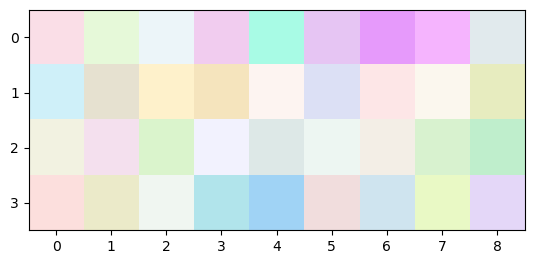

In [40]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def attention_image_summary(attn, image_shapes=None):
    attn = attn.float()
    batch_size, num_heads, query_length, memory_length = attn.shape
    
    # Step 1: Initial permutation
    image = attn.permute(0, 2, 3, 1)
    print(f"After permute: {image.shape}")
    
    # Step 2: High-dynamic-range adjustment
    image = torch.pow(image, 0.1)
    
    # Step 3: Padding to make the number of heads a multiple of 3
    if num_heads % 3 != 0:
        padding = 3 - (num_heads % 3)
        image = F.pad(image, (0, padding))
    print(f"After padding: {image.shape}")
    
    # Step 4: Split the last dimension into RGB channels
    image = image.view(batch_size, query_length, memory_length, 3, -1)
    print(f"After view for RGB channels: {image.shape}")
    image = image.max(dim=-1)[0]
    print(f"After max: {image.shape}")
    
    if image_shapes is not None:
        if len(image_shapes) == 4:
            q_rows, q_cols, m_rows, m_cols = image_shapes
            image = image.reshape(batch_size, q_rows, q_cols, m_rows, m_cols, 3)
            print(f"After reshape (4D): {image.shape}")
            image = image.permute(0, 1, 3, 2, 4, 5)
            print(f"After permute (4D): {image.shape}")
            image = image.reshape(batch_size, q_rows * m_rows, q_cols * m_cols, 3)
            print(f"After final reshape (4D): {image.shape}")
        else:
            assert len(image_shapes) == 6
            q_rows, q_cols, q_channels, m_rows, m_cols, m_channels = image_shapes
            image = image.reshape(batch_size, q_rows, q_cols, q_channels, m_rows, m_cols, m_channels, 3)
            print(f"After reshape (6D): {image.shape}")
            image = image.permute(0, 1, 4, 3, 2, 5, 6, 7)
            print(f"After permute (6D): {image.shape}")
            image = image.reshape(batch_size, q_rows * m_rows * q_channels, q_cols * m_cols * m_channels, 3)
            print(f"After final reshape (6D): {image.shape}")
    
    grid = make_grid(image, nrow=4)
    return grid

attn = torch.rand(1, 3, 6, 6)
image_shapes = (2, 3, 2, 3)
grid = attention_image_summary(attn, image_shapes)
print(grid.shape)
plt.imshow(grid.permute(0, 1, 2))
plt.show()


After permute: torch.Size([1, 8, 8, 4])
After padding: torch.Size([1, 8, 8, 6])
After view for RGB channels: torch.Size([1, 8, 8, 3, 2])
After max: torch.Size([1, 8, 8, 3])
After reshape (4D): torch.Size([1, 2, 4, 2, 4, 3])
After permute (4D): torch.Size([1, 2, 2, 4, 4, 3])
After final reshape (4D): torch.Size([1, 4, 16, 3])


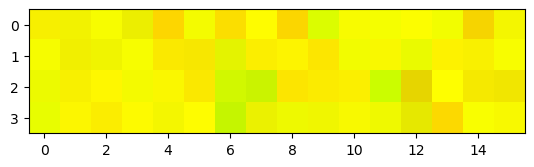

In [41]:
# Example 2
attn = torch.rand(1, 4, 8, 8)
image_shapes = (2, 4, 2, 4)
grid3 = attention_image_summary(attn, image_shapes)
plt.imshow(grid3.permute(0, 1, 2))
plt.show()

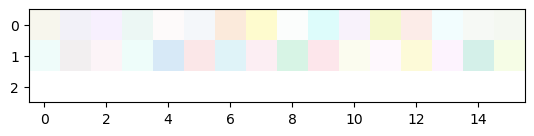

In [42]:
plt.imshow(grid3.permute(2, 1, 0))
plt.show()

In [44]:
class LshGating:
    """Class to split key/queries into separate buckets."""

    def __init__(self, depth, nb_hyperplanes, nb_replicat=1, trainable=False):
        """Construct the gating function parameters.

        Compute the gates for a single head.

        Args:
            depth (int): Dimension of the key/queries to dispatch
            nb_hyperplanes (int): Nb of vectors use to split the space. Will determine
                the number of buckets (2^nb_hyperplanes - 1).
            nb_replicat (int): Redundancy to avoid the edge cases (to be in one bucket
                the input should be in a majority)
            trainable (bool): If True, a balance loss is added to force the hyperplane
                to divide the key/query space evenly
        """
        self.depth = depth
        self.nb_hyperplanes = nb_hyperplanes
        self.nb_buckets = 2**nb_hyperplanes
        self.nb_replicat = nb_replicat  # Unused for now
        self.trainable = trainable  # Unused for now

        self.dispatchers = {}

        assert self.nb_replicat == 1  # For now

        # Vectors defining the hyperplanes
        self.t_vectors = nn.Parameter(
            torch.randn(self.depth, self.nb_hyperplanes * self.nb_replicat),
            requires_grad=self.trainable
        )

        # Projection vector from the bit space to similarity score space
        self.t_group = torch.tensor(
            [self._idx_to_bits(i) for i in range(self.nb_buckets)],
            dtype=torch.float32
        )

    def _idx_to_bits(self, i):
        """Convert a group index to its bit representation."""
        bits = bin(i)[2:].zfill(self.nb_hyperplanes)  # Pad the bits str with 0
        return [-1.0 if b == "0" else 1.0 for b in bits]

    def get_gates(self, x):
        """Return the bucket id of the given tensor.

        Args:
            x (torch.Tensor): float32 of shape [length, depth]

        Returns:
            torch.Tensor: One-hot vector int64 of shape [length, nb_buckets]
                containing the id of the bucket
        """
        # The balance loss doesn't propagate to the rest of the network
        x = x.detach()
        # [length, depth] * [depth, nb_vectors * replicat]
        x = torch.matmul(x, self.t_vectors)
        # [length, nb_vector * replicat]
        x = torch.sign(x)  # Get on which side of the hyperplane the keys are.

        # x = torch.reshape(x, [-1, nb_replicat, nb_vector])
        # [length, replicat, nb_vector] * [nb_vector, 2^nb_vector - 1]

        x = torch.matmul(x, self.t_group.T) / self.nb_hyperplanes
        # We get a similarity score for each of the group between [-1, 1]
        # [length, (replicat,) 2^nb_vector - 1]
        # Do an argmax to get the most likely group for each replicat
        x = torch.argmax(x, dim=-1)
        # [length(, replicat)]
        # One-hot for compatibility with the sparse dispatcher
        x = F.one_hot(x, num_classes=self.nb_buckets).float()
        # TODO: Use a loss to force an even distribution
        return x


In [45]:
depth = 128
nb_hyperplanes = 3
nb_replicat = 1
trainable = False

# Create the LshGating object
lsh_gating = LshGating(depth, nb_hyperplanes, nb_replicat, trainable)

# Create a random input tensor with shape [length, depth]
length = 10
x = torch.randn(length, depth)

# Get the gates
gates = lsh_gating.get_gates(x)

print("Input tensor:")
print(x)
print("Gates:")
print(gates)

Input tensor:
tensor([[-0.5303,  1.4905, -1.5894,  ..., -1.8739,  0.0559,  1.3020],
        [-1.0969,  1.1514,  0.9657,  ...,  0.7325,  0.5438,  0.1793],
        [ 0.8321, -0.2404, -0.5941,  ..., -0.1287,  1.8788, -0.7253],
        ...,
        [ 0.0915, -0.8558,  0.2161,  ..., -0.5130,  0.4481, -0.6586],
        [ 0.8867,  0.4651,  0.9278,  ..., -0.4566,  0.1386,  0.9797],
        [-0.7290, -0.6930, -0.3408,  ..., -0.3214,  0.1912, -0.9949]])
Gates:
tensor([[0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.]])


## 2.7 Attention2D 

In [50]:

def split_heads_2d(x, num_heads):
    """
    Split channels (dimension 3) into multiple heads (becomes dimension 1).
    
    Args:
    x: a Tensor with shape [batch, height, width, channels]
    num_heads: an integer
    
    Returns:
    a Tensor with shape [batch, num_heads, height, width, channels / num_heads]
    """
    batch_size, height, width, channels = x.size()
    assert channels % num_heads == 0, "channels must be divisible by num_heads"
    new_channels = channels // num_heads
    x = x.view(batch_size, height, width, num_heads, new_channels)
    return x.permute(0, 3, 1, 2, 4)

In [52]:
# Example input tensor with shape [batch, height, width, channels]
x = torch.randn(2, 4, 4, 8)

# Number of heads
num_heads = 2

# Split heads
split_tensor = split_heads_2d(x, num_heads)

print("Input tensor shape:", x.shape)
print("Split tensor shape:", split_tensor.shape)
#print("Split tensor:")
#print(split_tensor)

Input tensor shape: torch.Size([2, 4, 4, 8])
Split tensor shape: torch.Size([2, 2, 4, 4, 4])
Split tensor:


In [54]:
def combine_heads_2d(x):
    """Inverse of split_heads_2d.

    Args:
        x: a Tensor with shape
          [batch, num_heads, height, width, channels / num_heads]

    Returns:
        a Tensor with shape [batch, height, width, channels]
    """
    batch_size, num_heads, height, width, new_channels = x.size()
    x = x.permute(0, 2, 3, 1, 4).contiguous()
    x = x.view(batch_size, height, width, num_heads * new_channels)
    return x

In [55]:
# Example input tensor after splitting heads with shape [batch, num_heads, height, width, channels / num_heads]
x_split = torch.randn(2, 2, 4, 4, 4)

# Combine heads
combined_tensor = combine_heads_2d(x_split)

print("Input split tensor shape:", x_split.shape)
print("Combined tensor shape:", combined_tensor.shape)
#print("Combined tensor:")
#print(combined_tensor)

Input split tensor shape: torch.Size([2, 2, 4, 4, 4])
Combined tensor shape: torch.Size([2, 4, 4, 8])
